# 1. Khai báo thư viện ảnh

(np.float64(-0.5), np.float64(625.5), np.float64(314.5), np.float64(-0.5))

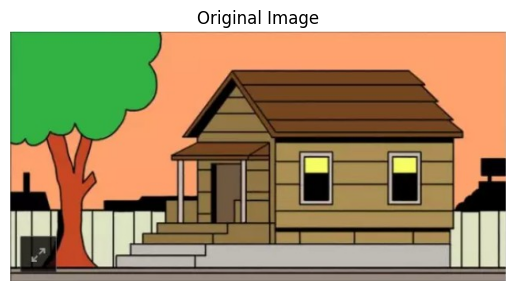

In [2]:
import numpy as np
import cv2
from matplotlib import pyplot as vuong

img = cv2.imread('house.jpg')

vuong.imshow(img[:,:,::-1])
vuong.title("Original Image")
vuong.axis("off")

# 2. Harris Corner Detection 

(np.float64(-0.5), np.float64(625.5), np.float64(314.5), np.float64(-0.5))

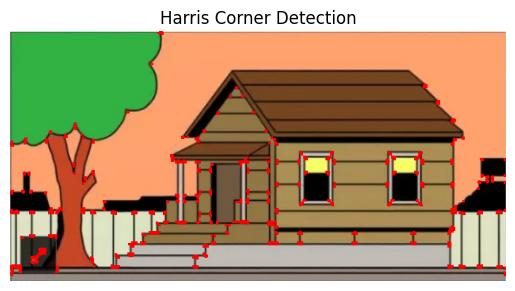

In [3]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

dst = cv2.cornerHarris(gray,2,3,0.04)
dst = cv2.dilate(dst,None)

img_harris = img.copy()
img_harris[dst > 0.01*dst.max()] = [0,0,255]

vuong.imshow(img_harris[:,:,::-1])
vuong.title("Harris Corner Detection")
vuong.axis("off")

# 3. Difference of Gaussians (Band-pass filtering)

(np.float64(-0.5), np.float64(625.5), np.float64(314.5), np.float64(-0.5))

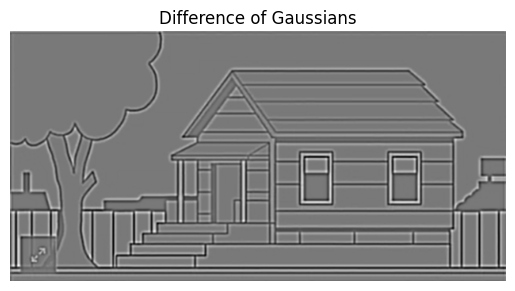

In [4]:
blur1 = cv2.GaussianBlur(gray,(5,5),0)
blur2 = cv2.GaussianBlur(gray,(9,9),0)

dog = blur1 - blur2

vuong.imshow(dog,cmap='gray')
vuong.title("Difference of Gaussians")
vuong.axis("off")

# 4. Automatic Scale Selection

(np.float64(-0.5), np.float64(625.5), np.float64(314.5), np.float64(-0.5))

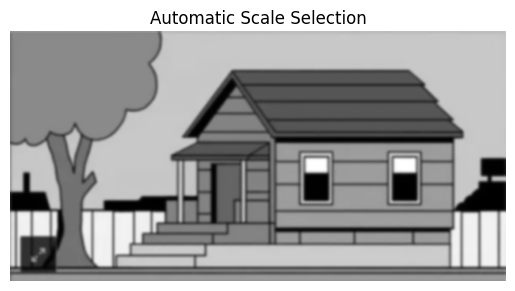

In [5]:
scales = [3,5,7,9]
responses = []

for s in scales:
    blur = cv2.GaussianBlur(gray,(s,s),0)
    responses.append(blur)

vuong.imshow(responses[2],cmap='gray')
vuong.title("Automatic Scale Selection")
vuong.axis("off")

# 5. Scale Invariant Detection

(np.float64(-0.5), np.float64(625.5), np.float64(314.5), np.float64(-0.5))

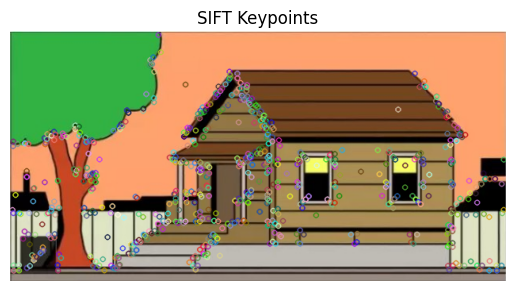

In [7]:
sift = cv2.SIFT_create()

gray_u8 = cv2.convertScaleAbs(gray)
kp, des = sift.detectAndCompute(gray_u8, None)

img_sift = cv2.drawKeypoints(img,kp,None)

vuong.imshow(img_sift[:,:,::-1])
vuong.title("SIFT Keypoints")
vuong.axis("off")

# 6. Scale-space Blob Detector

(np.float64(-0.5), np.float64(625.5), np.float64(314.5), np.float64(-0.5))

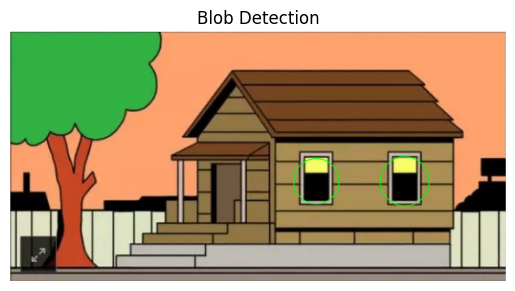

In [9]:
blob = cv2.SimpleBlobDetector_create()

keypoints = blob.detect(gray_u8)

img_blob = cv2.drawKeypoints(img,keypoints,None,(0,255,0),
                             cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

vuong.imshow(img_blob[:,:,::-1])
vuong.title("Blob Detection")
vuong.axis("off")

# 7. Bag of Words

In [15]:
orb = cv2.ORB_create()

orb = cv2.ORB_create()

kp, des = orb.detectAndCompute(gray_u8, None)

print("Number of keypoints:", len(kp))

Number of keypoints: 500


# 8. Image Panorama

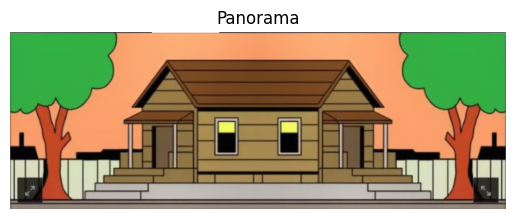

In [13]:
img_flip = cv2.flip(img,1)

stitcher = cv2.Stitcher_create()

status, pano = stitcher.stitch([img, img_flip])

if status == cv2.Stitcher_OK:
    vuong.imshow(pano[:,:,::-1])
    vuong.title("Panorama")
    vuong.axis("off")
else:
    print("Stitching failed")

# 9. Automatic Mosaicing

(np.float64(-0.5), np.float64(1251.5), np.float64(314.5), np.float64(-0.5))

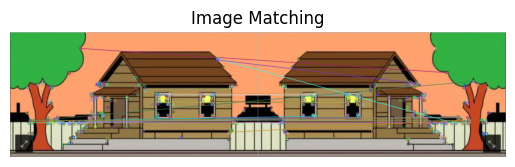

In [14]:
orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(img,None)
kp2, des2 = orb.detectAndCompute(img_flip,None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING)

matches = bf.match(des1,des2)

img_match = cv2.drawMatches(img,kp1,img_flip,kp2,matches[:20],None)

vuong.imshow(img_match[:,:,::-1])
vuong.title("Image Matching")
vuong.axis("off")

# 10. Wide Baseline Stereo

(np.float64(-0.5), np.float64(625.5), np.float64(314.5), np.float64(-0.5))

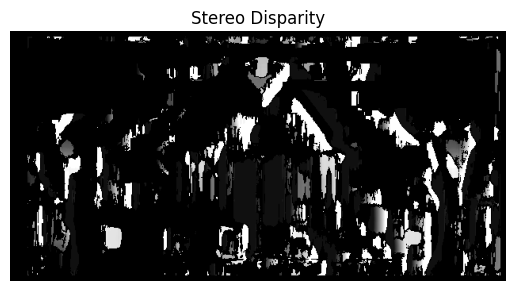

In [16]:
stereo = cv2.StereoBM_create(numDisparities=16, blockSize=15)

imgL = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
imgR = cv2.flip(imgL,1)

disparity = stereo.compute(imgL,imgR)

vuong.imshow(disparity,cmap='gray')
vuong.title("Stereo Disparity")
vuong.axis("off")

# 11. CBIR (content-based image retrieval)

Text(0.5, 1.0, 'Image Histogram Feature')

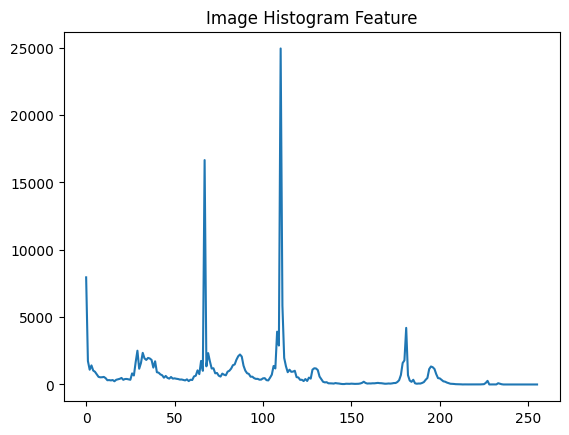

In [17]:
hist = cv2.calcHist([img],[0],None,[256],[0,256])

vuong.plot(hist)
vuong.title("Image Histogram Feature")

# 12. Bag of Words với SIFT + Histogram

In [21]:
gray_sift = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

kp, des = sift.detectAndCompute(gray_sift, None)

if des is not None:
    hist = np.histogram(des, bins=20)
    print("Histogram of SIFT descriptors:")
    print(hist[0])

Histogram of SIFT descriptors:
[60323  9410  5628  4231  2831  2269  1697  1578  1236  1188  1264  2012
  2051  1182   663   254   169    25    16    21]
